# 🛕 Heritage Temple Damage — MoE Ensemble
### Mixture-of-Experts: ResNet50 · EfficientNet-B4 · ViT-B16 · YOLO-damage
**Primary expert**: AI gating network learns which expert to trust per image.  
**Fallback chain**: if primary confidence < threshold → ensemble average → mock.  
**Outputs**: damage location heatmap + criticality grade (STABLE / MINOR / MODERATE / CRITICAL)


In [1]:
%%capture
!pip install ultralytics timm grad-cam torch-ema albumentations \
             roboflow scikit-learn seaborn --quiet

import os, random, json, shutil, time, platform
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import torchvision.transforms as T
import cv2
import timm
from torch_ema import ExponentialMovingAverage
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm.auto import tqdm

assert torch.cuda.is_available(), "Enable GPU: Run > Change runtime > T4 GPU x2"
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"CUDA : {torch.version.cuda}")


## ⚙️ Section 1 — Configuration

In [10]:
# ─── EDIT THESE ──────────────────────────────────────────────────────────────
KAGGLE_USERNAME = "shresthaadi"
KAGGLE_KEY      = "KGAT_1f98c660851dc644dce74df1978f1c19"

GLOBAL_SEED     = 42
BASE_DIR        = Path("/kaggle/working")

# ── Class schema ──────────────────────────────────────────────────────────────
CLASS_NAMES     = ["Undamaged", "Partial Damage", "Damaged"]
NUM_CLASSES     = len(CLASS_NAMES)
CRITICALITY_MAP = {
    "Undamaged":      "STABLE",
    "Partial Damage": "MINOR",
    "Damaged":        "CRITICAL",
}

# ── Expert training ───────────────────────────────────────────────────────────
IMAGE_SIZE      = 224
BATCH_SIZE      = 32
NUM_WORKERS     = 4
EXPERT_EPOCHS   = 10
STAGE1_EPOCHS   = 2
STAGE2_EPOCHS   = 6
LR_HEAD         = 1e-3
LR_LAYER4       = 2e-5
LR_MIN          = 1e-7
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1
GRAD_CLIP       = 1.0
EMA_DECAY       = 0.9998
MIXUP_ALPHA     = 0.4
DROPOUT         = 0.4

# ── Gating network training ───────────────────────────────────────────────────
GATE_EPOCHS     = 7
GATE_LR         = 3e-4
GATE_HIDDEN     = 256

# ── Inference ─────────────────────────────────────────────────────────────────a
CONF_THRESHOLD  = 0.70
NUM_EXPERTS     = 4

# ── Directories ───────────────────────────────────────────────────────────────
DIRS = {
    "data":     BASE_DIR / "data",
    "raw":      BASE_DIR / "raw",
    "weights":  BASE_DIR / "weights",
    "outputs":  BASE_DIR / "outputs",
    "gradcam":  BASE_DIR / "gradcam",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

DATA_DIR    = DIRS["data"]
WEIGHTS_DIR = DIRS["weights"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")


Device : cuda
Classes: ['Undamaged', 'Partial Damage', 'Damaged']


In [3]:
def seed_everything(seed=GLOBAL_SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()

def save_checkpoint(state, name):
    path = WEIGHTS_DIR / name
    torch.save(state, path)
    print(f"  Saved → {path}")

def load_checkpoint(name):
    path = WEIGHTS_DIR / name
    if path.exists():
        return torch.load(path, map_location=DEVICE)
    return None


## 📥 Section 2 — Dataset Download

In [4]:
import os, json
from pathlib import Path

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

RAW = DIRS["raw"]

DATASETS = [
    ("arnavr10880/concrete-crack-images-for-classification", "concrete_cracks"),
    ("arunrk7/surface-crack-detection",                      "surface_cracks"),
    ("anasmohammedtahir/aider",                              "aider"),
    ("varpit94/disaster-images-dataset",                     "disaster"),
    ("doken/quakeset",                                       "quakeset"),
]

for dataset_id, folder in DATASETS:
    dest = RAW / folder
    if dest.exists() and sum(1 for _ in dest.rglob("*") if _.is_file()) > 10:
        print(f"  SKIP  {folder:<35} ({sum(1 for _ in dest.rglob('*') if _.is_file())} files)")
        continue
    dest.mkdir(parents=True, exist_ok=True)
    ret = os.system(f"kaggle datasets download -d {dataset_id} -p {dest} --unzip -q")
    n   = sum(1 for _ in dest.rglob("*") if _.is_file())
    print(f"  {'OK' if ret == 0 else 'FAIL'}  {folder:<35} ({n} files)")


Dataset URL: https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification
License(s): Attribution 4.0 International (CC BY 4.0)
  OK  concrete_cracks                     (40000 files)
Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors
  OK  surface_cracks                      (40000 files)
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
  FAIL  aider                               (0 files)
Dataset URL: https://www.kaggle.com/datasets/varpit94/disaster-images-dataset
License(s): other
  OK  disaster                            (13557 files)
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
  FAIL  quakeset                            (0 files)


## 🗂️ Section 3 — Organise into train/val/test

In [5]:
import shutil, random
from pathlib import Path

seed_everything()

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SPLITS   = {"train": 0.70, "val": 0.15, "test": 0.15}

for split in SPLITS:
    for cls in CLASS_NAMES:
        (DATA_DIR / split / cls).mkdir(parents=True, exist_ok=True)

RAW = DIRS["raw"]
SOURCES = [
    (RAW / "disaster/Comprehensive Disaster Dataset(CDD)/Non_Damage/Non_Damage_Buildings_Street",
                                                                  "Undamaged",    None),
    (RAW / "concrete_cracks/Negative",                            "Undamaged",    1500),
    (RAW / "surface_cracks/Positive",                             "Partial Damage", 4000),
    (RAW / "concrete_cracks/Positive",                            "Partial Damage", 4000),
    (RAW / "disaster/Comprehensive Disaster Dataset(CDD)/Damaged_Infrastructure",
                                                                  "Damaged",      None),
    (RAW / "quakeset",                                            "Damaged",      2000),
    (RAW / "aider",                                               "Damaged",      2000),
]

def collect_images(folder, cap):
    imgs = [p for p in Path(folder).rglob("*")
            if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if cap and len(imgs) > cap:
        imgs = random.sample(imgs, cap)
    return imgs

def copy_split(images, cls, src_tag):
    random.shuffle(images)
    n = len(images)
    n_train = int(n * SPLITS["train"])
    n_val   = int(n * SPLITS["val"])
    buckets = (
        ("train", images[:n_train]),
        ("val",   images[n_train:n_train+n_val]),
        ("test",  images[n_train+n_val:]),
    )
    for split, imgs in buckets:
        for i, img in enumerate(imgs):
            dst = DATA_DIR / split / cls / f"{src_tag}_{i:05d}{img.suffix}"
            shutil.copy2(img, dst)

for folder, cls, cap in SOURCES:
    folder = Path(folder)
    if not folder.exists():
        print(f"  MISSING {folder}")
        continue
    imgs = collect_images(folder, cap)
    tag  = folder.name[:12].replace(" ", "_")
    copy_split(imgs, cls, tag)
    print(f"  {cls:<18} <- {folder.name[:40]} ({len(imgs)} images)")

print("\nClass distribution:")
for split in SPLITS:
    for cls in CLASS_NAMES:
        n = len(list((DATA_DIR / split / cls).glob("*")))
        print(f"  {split:6s} / {cls:<18}: {n:5d}")


  Undamaged          <- Non_Damage_Buildings_Street (4572 images)
  Undamaged          <- Negative (1500 images)
  Partial Damage     <- Positive (4000 images)
  Partial Damage     <- Positive (4000 images)
  Damaged            <- Damaged_Infrastructure (1454 images)
  Damaged            <- quakeset (0 images)
  Damaged            <- aider (0 images)

Class distribution:
  train  / Undamaged         :  4250
  train  / Partial Damage    :  2800
  train  / Damaged           :  1017
  val    / Undamaged         :   910
  val    / Partial Damage    :   600
  val    / Damaged           :   218
  test   / Undamaged         :   912
  test   / Partial Damage    :   600
  test   / Damaged           :   219


## 🔧 Section 4 — Transforms & Dataset

In [6]:
sz   = IMAGE_SIZE
mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

train_tfm = A.Compose([
    A.RandomResizedCrop(size=(sz, sz), scale=(0.65, 1.0), ratio=(0.75, 1.33)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Rotate(limit=20, p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
    A.CLAHE(clip_limit=3.0, p=0.35),
    A.RandomShadow(p=0.2),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.25),
    A.OneOf([A.MotionBlur(blur_limit=5), A.GaussianBlur(blur_limit=5)], p=0.2),
    A.ImageCompression(quality_range=(75, 95), p=0.2),
    A.CoarseDropout(num_holes_range=(1, 6),
                    hole_height_range=(8, sz//10),
                    hole_width_range=(8, sz//10), fill=0, p=0.25),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

val_tfm = A.Compose([
    A.Resize(sz, sz),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])


class DamageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
        self.samples = [
            (str(p), self.class_to_idx[p.parent.name])
            for cls in CLASS_NAMES
            for p in (Path(root) / cls).iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        ]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label


def get_dataloaders():
    train_ds = DamageDataset(DATA_DIR / "train", train_tfm)
    val_ds   = DamageDataset(DATA_DIR / "val",   val_tfm)
    test_ds  = DamageDataset(DATA_DIR / "test",  val_tfm)

    labels   = [s[1] for s in train_ds.samples]
    counts   = np.bincount(labels)
    weights  = 1.0 / counts[labels]
    sampler  = WeightedRandomSampler(weights, len(weights))

    loader_kw = dict(num_workers=NUM_WORKERS, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, **loader_kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kw)

    print(f"Train: {len(train_ds):5d} | Val: {len(val_ds):5d} | Test: {len(test_ds):5d}")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders()


Train:  8067 | Val:  1728 | Test:  1731


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 🏗️ Section 5 — Expert Model Builders

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing
        self.w     = weight

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets,
                               weight=self.w,
                               label_smoothing=self.ls,
                               reduction="none")
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


def build_resnet50():
    m = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
    for p in m.parameters(): p.requires_grad = False
    m.fc = nn.Sequential(
        nn.BatchNorm1d(2048), nn.Dropout(DROPOUT),
        nn.Linear(2048, 512), nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),  nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES),
    )
    return m

def build_efficientnet_b4():
    m = tvm.efficientnet_b4(weights=tvm.EfficientNet_B4_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(DROPOUT),
        nn.Linear(in_f, 512), nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES),
    )
    return m

def build_vit_b16():
    m = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
    for p in m.parameters(): p.requires_grad = False
    embed_dim = m.embed_dim
    head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Linear(embed_dim, 256), nn.GELU(),
        nn.Dropout(DROPOUT),
        nn.Linear(256, NUM_CLASSES),
    )
    m.head = head
    for block in m.blocks[-4:]:
        for p in block.parameters(): p.requires_grad = True
    for p in m.head.parameters(): p.requires_grad = True
    return m

class YOLOFeatureClassifier(nn.Module):
    def __init__(self, yolo_weights_path=None):
        super().__init__()
        self._yolo_loaded = False
        self.feature_dim  = 512

        if yolo_weights_path and Path(yolo_weights_path).exists():
            try:
                from ultralytics import YOLO
                yolo = YOLO(str(yolo_weights_path))
                self.backbone = yolo.model.model[:10]
                for p in self.backbone.parameters(): p.requires_grad = False
                self._yolo_loaded = True
                print(f"  YOLO backbone loaded from {yolo_weights_path}")
            except Exception as e:
                print(f"  YOLO backbone load failed: {e} — using fallback conv")

        if not self._yolo_loaded:
            self.backbone = nn.Sequential(
                nn.Conv2d(3, 64, 7, stride=2, padding=3), nn.BatchNorm2d(64), nn.ReLU(),
                nn.MaxPool2d(3, stride=2, padding=1),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
                nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
                nn.AdaptiveAvgPool2d(1),
            )
            self.feature_dim = 256

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_dim, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x):
        feats = self.backbone(x)
        if feats.dim() == 4:
            feats = self.pool(feats)
        return self.head(feats)

def build_yolo_damage(yolo_weights=None):
    return YOLOFeatureClassifier(yolo_weights)


EXPERT_BUILDERS = {
    "resnet50":         build_resnet50,
    "efficientnet_b4":  build_efficientnet_b4,
    "vit_b16":          build_vit_b16,
    "yolo_damage":      lambda: build_yolo_damage(
                            WEIGHTS_DIR / "yolo_best.pt"
                        ),
}

print("Expert builders defined:")
for name in EXPERT_BUILDERS:
    print(f"  {name}")


Expert builders defined:
  resnet50
  efficientnet_b4
  vit_b16
  yolo_damage


## 🏋️ Section 6 — Expert Training Loop (two-stage)

In [8]:
def get_optimizer(model, stage):
    if stage == 1:
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=LR_HEAD, weight_decay=WEIGHT_DECAY)

    try:
        groups = [
            {"params": model.layer4.parameters(), "lr": LR_LAYER4},
            {"params": model.layer3.parameters(), "lr": LR_LAYER4 / 2},
        ]
        head_p = list(model.fc.parameters()) if hasattr(model, "fc") else \
                 list(model.head.parameters())
        groups.append({"params": head_p, "lr": LR_HEAD})
    except AttributeError:
        groups = [{"params": [p for p in model.parameters() if p.requires_grad],
                   "lr": LR_HEAD * 0.1}]
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)


def unfreeze_all(model):
    for p in model.parameters(): p.requires_grad = True


def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0)).to(DEVICE)
    return lam * images + (1 - lam) * images[idx], labels, labels[idx], lam


def evaluate_expert(model, ema, loader):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    criterion = FocalLoss(gamma=2.0, label_smoothing=LABEL_SMOOTHING)
    with ema.average_parameters():
        with torch.no_grad():
            for imgs, lbls in loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, lbls)
                total_loss += loss.item() * len(imgs)
                all_preds.extend(out.argmax(1).cpu().tolist())
                all_labels.extend(lbls.cpu().tolist())
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    f1  = f1_score(all_labels, all_preds, average="weighted")
    return total_loss / len(all_labels), acc, f1, all_preds, all_labels


def train_expert(name, model, resume=True):
    print(f"\n{'='*55}\n  Training expert: {name}\n{'='*55}")

    ckpt_best   = f"{name}_best.pth"
    ckpt_latest = f"{name}_latest.pth"

    model = model.to(DEVICE)
    ema   = ExponentialMovingAverage(model.parameters(), decay=EMA_DECAY)

    criterion = FocalLoss(gamma=2.0, label_smoothing=LABEL_SMOOTHING)
    scaler    = GradScaler()

    best_f1      = 0.0
    start_epoch  = 0
    stage        = 1
    patience     = 0
    history      = defaultdict(list)

    labels  = [s[1] for s in train_loader.dataset.samples]
    counts  = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    weights = torch.tensor(1.0 / (counts + 1e-6), dtype=torch.float32).to(DEVICE)
    weights = weights / weights.sum() * NUM_CLASSES
    criterion.w = weights

    if resume:
        ckpt = load_checkpoint(ckpt_latest)
        if ckpt:
            model.load_state_dict(ckpt["model_state"])
            ema.load_state_dict(ckpt["ema_state"])
            best_f1     = ckpt["best_f1"]
            start_epoch = ckpt["epoch"] + 1
            stage       = ckpt.get("stage", 1)
            history     = defaultdict(list, ckpt.get("history", {}))
            print(f"  Resumed epoch {start_epoch} | F1 {best_f1:.4f}")

    optimizer = get_optimizer(model, stage)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EXPERT_EPOCHS - STAGE1_EPOCHS, eta_min=LR_MIN
    )

    for epoch in range(start_epoch, EXPERT_EPOCHS):
        if epoch == STAGE1_EPOCHS and stage == 1:
            stage = 2
            print(f"  → Stage 2: unfreeze all layers")
            unfreeze_all(model)
            optimizer = get_optimizer(model, stage)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=STAGE2_EPOCHS, eta_min=LR_MIN
            )

        model.train()
        train_loss, train_correct, n = 0.0, 0, 0

        for imgs, lbls in tqdm(train_loader, desc=f"E{epoch+1:02d}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

            if stage == 2 and np.random.random() < 0.5:
                imgs, la, lb, lam = mixup_batch(imgs, lbls)
                with autocast():
                    out  = model(imgs)
                    loss = lam * criterion(out, la) + (1 - lam) * criterion(out, lb)
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, lbls)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad()
            ema.update()

            train_loss    += loss.item() * len(imgs)
            train_correct += (out.argmax(1) == lbls).sum().item()
            n             += len(imgs)

        scheduler.step()
        train_loss /= n
        train_acc   = train_correct / n

        val_loss, val_acc, val_f1, _, _ = evaluate_expert(model, ema, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        print(f"  E{epoch+1:02d} | trn_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            patience = 0
            save_checkpoint({"model_state": model.state_dict(),
                             "ema_state":   ema.state_dict(),
                             "epoch": epoch, "best_f1": best_f1,
                             "stage": stage, "history": dict(history)}, ckpt_best)
        else:
            patience += 1
            if patience >= 10:
                print(f"  Early stop at epoch {epoch+1}")
                break

        save_checkpoint({"model_state": model.state_dict(),
                         "ema_state":   ema.state_dict(),
                         "epoch": epoch, "best_f1": best_f1,
                         "stage": stage, "history": dict(history)}, ckpt_latest)

    print(f"  Best val F1: {best_f1:.4f}")
    return best_f1


## 🚀 Section 7 — Train All Experts

In [11]:
expert_results = {}

for expert_name, builder in EXPERT_BUILDERS.items():
    model = builder()
    f1    = train_expert(expert_name, model, resume=True)
    expert_results[expert_name] = f1
    del model; torch.cuda.empty_cache()

print("\nExpert F1 scores:")
for name, f1 in expert_results.items():
    print(f"  {name:<20}: {f1:.4f}")



  Training expert: resnet50


/tmp/ipykernel_57/872861025.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


  Resumed epoch 13 | F1 0.9864
  Best val F1: 0.9864
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 188MB/s] 



  Training expert: efficientnet_b4


...

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
/tmp/ipykernel_57/872861025.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_57/872861025.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


  E09 | trn_loss=0.1337 | val_acc=0.7153 | val_F1=0.7365
  Saved → /kaggle/working/weights/yolo_damage_latest.pth


E10:   0%|          | 0/253 [00:00<?, ?it/s]

/tmp/ipykernel_57/872861025.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_57/872861025.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Premature end of JPEG file
Premature end of JPEG file


  E10 | trn_loss=0.1359 | val_acc=0.7512 | val_F1=0.7725
  Saved → /kaggle/working/weights/yolo_damage_best.pth
  Saved → /kaggle/working/weights/yolo_damage_latest.pth
  Best val F1: 0.7725

Expert F1 scores:
  resnet50            : 0.9864
  efficientnet_b4     : 0.9725
  vit_b16             : 0.9942
  yolo_damage         : 0.7725


## 🧠 Section 8 — Gating Network

In [12]:
class ExpertFeatureExtractor(nn.Module):
    """Wraps a trained expert — returns (features, logits)."""
    def __init__(self, model, feature_dim):
        super().__init__()
        self.model       = model
        self.feature_dim = feature_dim

    def forward(self, x):
        if hasattr(self.model, "layer4"):
            feats = nn.Sequential(*list(self.model.children())[:-1])(x)
            feats = feats.flatten(1)
            logits = self.model.fc(feats)
        elif hasattr(self.model, "features"):
            feats  = self.model.features(x)
            feats  = self.model.avgpool(feats).flatten(1)
            logits = self.model.classifier(feats)
        elif hasattr(self.model, "blocks"):
            feats  = self.model.forward_features(x)
            if feats.dim() == 3:
                feats = feats[:, 0]
            logits = self.model.head(feats)
        else:
            feats  = self.model.backbone(x)
            if feats.dim() == 4:
                feats = nn.AdaptiveAvgPool2d(1)(feats).flatten(1)
            logits = self.model.head(feats)
        return feats, logits


class GatingNetwork(nn.Module):
    """
    Learns to weight each expert given the image.
    Input : concatenated feature vectors from all N experts [B, N * feat_dim]
    Output: weight vector [B, N] (softmax)

    During inference:
      max(gate_weight) >= CONF_THRESHOLD → use top expert
      else                               → weighted average of all experts
    """
    def __init__(self, expert_dims, hidden=GATE_HIDDEN, n_experts=NUM_EXPERTS):
        super().__init__()
        in_dim = sum(expert_dims)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(hidden // 2, n_experts),
        )
        self.n_experts = n_experts

    def forward(self, features_list):
        x       = torch.cat(features_list, dim=1)
        logits  = self.net(x)
        weights = F.softmax(logits, dim=1)
        return weights

    def load_balance_loss(self, weights):
        """Switch Transformer load-balancing penalty."""
        f = weights.mean(0)
        return self.n_experts * (f * f).sum()


class MoEDamageClassifier(nn.Module):
    """Full MoE: runs all experts, gates, fuses, outputs class + criticality."""
    def __init__(self, expert_extractors, gate):
        super().__init__()
        self.experts = nn.ModuleList(expert_extractors)
        self.gate    = gate

    def forward(self, x):
        all_feats, all_logits = [], []
        for expert in self.experts:
            feats, logits = expert(x)
            all_feats.append(feats)
            all_logits.append(logits)

        gate_weights = self.gate(all_feats)

        stacked = torch.stack(all_logits, dim=1)
        fused   = (gate_weights.unsqueeze(-1) * stacked).sum(dim=1)

        return fused, gate_weights, all_logits

    @torch.no_grad()
    def predict(self, x, conf_threshold=CONF_THRESHOLD):
        self.eval()
        fused, gate_w, expert_logits = self(x)

        probs  = F.softmax(fused, dim=1)
        conf, pred_idx = probs.max(1)

        gate_max = gate_w.max(1).values
        used_fallback = (gate_max < conf_threshold).any().item()

        predicted_class = CLASS_NAMES[pred_idx[0].item()]
        criticality     = CRITICALITY_MAP[predicted_class]

        per_expert_preds = []
        for logits in expert_logits:
            p = F.softmax(logits, dim=1)
            c, ci = p.max(1)
            per_expert_preds.append({
                "class": CLASS_NAMES[ci[0].item()],
                "confidence": float(c[0].item()),
            })

        return {
            "predicted_class": predicted_class,
            "confidence":      float(conf[0].item()),
            "criticality":     criticality,
            "gate_weights":    gate_w[0].cpu().tolist(),
            "per_expert":      per_expert_preds,
            "used_fallback":   used_fallback,
            "class_probs": {
                CLASS_NAMES[i]: float(p)
                for i, p in enumerate(probs[0].cpu().tolist())
            },
        }

print("Gating network and MoE classifier defined.")


Gating network and MoE classifier defined.


## 📦 Section 9 — Assemble MoE

In [17]:
def load_expert(name, builder):
    model = builder().to(DEVICE)
    ckpt  = load_checkpoint(f"{name}_best.pth")
    if ckpt:
        model.load_state_dict(ckpt["model_state"])
        print(f"  Loaded {name} (F1={ckpt['best_f1']:.4f})")
    else:
        print(f"  WARNING: {name} weights not found — using random init")
    model.eval()
    return model

# 1. Define base expected dimensions as a fallback registry
BASE_FEAT_DIMS = {
    "resnet50":        2048,
    "efficientnet_b4": 1792,
    "vit_b16":         768,
    "yolo_damage":     512,
}

loaded_experts = {}
for name, builder in EXPERT_BUILDERS.items():
    loaded_experts[name] = load_expert(name, builder)

# 2. Build extractors and dynamically read their actual feature dimensions
extractors = []
actual_feat_dims = []

for name in EXPERT_BUILDERS:
    model = loaded_experts[name]
    # Check if model has a custom feature_dim property (like our YOLO wrapper does)
    dim = getattr(model, "feature_dim", BASE_FEAT_DIMS[name])
    
    extractor = ExpertFeatureExtractor(model, dim)
    extractor.eval()
    for p in extractor.parameters(): 
        p.requires_grad = False
        
    extractors.append(extractor)
    actual_feat_dims.append(dim)

# 3. Pass the dynamically calculated dimensions list directly to the Gate
gate = GatingNetwork(
    expert_dims=actual_feat_dims, 
    hidden=GATE_HIDDEN,
    n_experts=NUM_EXPERTS,
).to(DEVICE)

moe = MoEDamageClassifier(
    expert_extractors=[e.to(DEVICE) for e in extractors],
    gate=gate,
).to(DEVICE)

print("\nMoE assembled successfully:")
print(f"  Experts        : {list(EXPERT_BUILDERS.keys())}")
print(f"  Extracted Dims : {actual_feat_dims} (Total: {sum(actual_feat_dims)})")
print(f"  Gate hidden    : {GATE_HIDDEN}")

  Loaded resnet50 (F1=0.9864)
  Loaded efficientnet_b4 (F1=0.9725)
  Loaded vit_b16 (F1=0.9942)
  Loaded yolo_damage (F1=0.7725)

MoE assembled successfully:
  Experts        : ['resnet50', 'efficientnet_b4', 'vit_b16', 'yolo_damage']
  Extracted Dims : [2048, 1792, 768, 256] (Total: 4864)
  Gate hidden    : 256


## 🔀 Section 10 — Train Gating Network

In [18]:
gate_optimizer = torch.optim.AdamW(gate.parameters(), lr=GATE_LR, weight_decay=1e-4)
gate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    gate_optimizer, T_max=GATE_EPOCHS, eta_min=1e-6
)
ce_criterion   = nn.CrossEntropyLoss(label_smoothing=0.1)
LB_WEIGHT      = 0.01

gate_history = defaultdict(list)
best_gate_f1 = 0.0

for epoch in range(GATE_EPOCHS):
    moe.train()
    for e in moe.experts: e.eval()

    total_loss, correct, n = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f"Gate E{epoch+1:02d}", leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        fused, gate_weights, _ = moe(imgs)
        ce_loss  = ce_criterion(fused, lbls)
        lb_loss  = gate.load_balance_loss(gate_weights)
        loss     = ce_loss + LB_WEIGHT * lb_loss

        gate_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gate.parameters(), 1.0)
        gate_optimizer.step()

        total_loss += loss.item() * len(imgs)
        correct    += (fused.argmax(1) == lbls).sum().item()
        n          += len(imgs)

    gate_scheduler.step()

    moe.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(DEVICE)
            fused, _, _ = moe(imgs)
            val_preds.extend(fused.argmax(1).cpu().tolist())
            val_labels.extend(lbls.tolist())

    val_f1  = f1_score(val_labels, val_preds, average="weighted")
    val_acc = sum(p == l for p, l in zip(val_preds, val_labels)) / len(val_labels)

    gate_history["train_loss"].append(total_loss / n)
    gate_history["val_f1"].append(val_f1)

    print(f"  Gate E{epoch+1:02d} | loss={total_loss/n:.4f} | val_acc={val_acc:.4f} | val_F1={val_f1:.4f}")

    if val_f1 > best_gate_f1:
        best_gate_f1 = val_f1
        save_checkpoint({
            "gate_state":  gate.state_dict(),
            "epoch":       epoch,
            "best_f1":     best_gate_f1,
            "history":     dict(gate_history),
        }, "gate_best.pth")

print(f"\nBest gate F1: {best_gate_f1:.4f}")


Gate E01:   0%|          | 0/253 [00:00<?, ?it/s]

Premature end of JPEG file
Premature end of JPEG file


  Gate E01 | loss=0.3891 | val_acc=0.9959 | val_F1=0.9960
  Saved → /kaggle/working/weights/gate_best.pth


Gate E02:   0%|          | 0/253 [00:00<?, ?it/s]

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


...

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  Gate E06 | loss=0.3738 | val_acc=0.9959 | val_F1=0.9960


Gate E07:   0%|          | 0/253 [00:00<?, ?it/s]

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  Gate E07 | loss=0.3753 | val_acc=0.9965 | val_F1=0.9965

Best gate F1: 0.9971


## 📊 Section 11 — Evaluation & Analysis

Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]

Test Accuracy      : 0.9971
Test F1 (weighted) : 0.9971

                precision    recall  f1-score   support

     Undamaged       1.00      0.99      1.00       912
Partial Damage       1.00      1.00      1.00       600
       Damaged       0.98      1.00      0.99       219

      accuracy                           1.00      1731
     macro avg       0.99      1.00      1.00      1731
  weighted avg       1.00      1.00      1.00      1731



/tmp/ipykernel_57/2639185464.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(gate_arr, labels=expert_names, patch_artist=True)


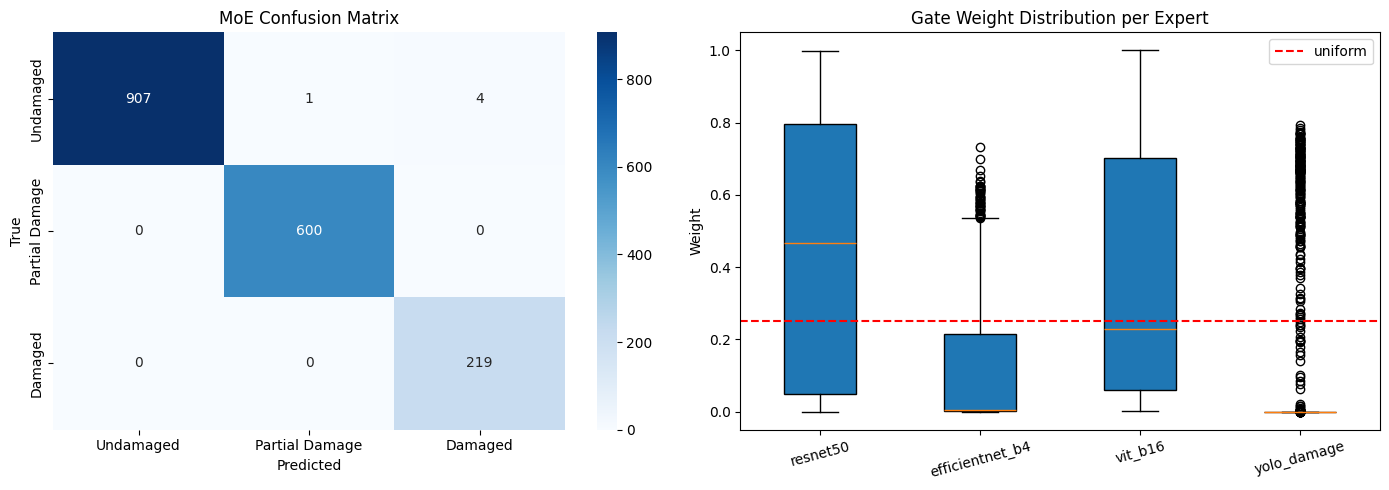

In [20]:
ckpt = load_checkpoint("gate_best.pth")
gate.load_state_dict(ckpt["gate_state"])
moe.eval()

all_preds, all_labels, all_confidences = [], [], []
gate_weight_log = []

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Evaluating"):
        imgs = imgs.to(DEVICE)
        fused, gate_weights, _ = moe(imgs)
        probs = F.softmax(fused, dim=1)
        confs, preds = probs.max(1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(lbls.tolist())
        all_confidences.extend(confs.cpu().tolist())
        gate_weight_log.extend(gate_weights.cpu().tolist())

test_f1  = f1_score(all_labels, all_preds, average="weighted")
test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

print(f"Test Accuracy      : {test_acc:.4f}")
print(f"Test F1 (weighted) : {test_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("MoE Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

gate_arr = np.array(gate_weight_log)
expert_names = list(EXPERT_BUILDERS.keys())
axes[1].boxplot(gate_arr, labels=expert_names, patch_artist=True)
axes[1].set_title("Gate Weight Distribution per Expert")
axes[1].set_ylabel("Weight"); axes[1].tick_params(axis="x", rotation=15)
axes[1].axhline(1/NUM_EXPERTS, color="red", linestyle="--", label="uniform")
axes[1].legend()

plt.tight_layout()
plt.savefig(DIRS["outputs"] / "moe_evaluation.png", dpi=130, bbox_inches="tight")
plt.show()

## 🔁 Section 12 — Fallback Chain Validation

In [21]:
from PIL import Image as PILImage

def predict_single(pil_image, moe_model, conf_threshold=CONF_THRESHOLD):
    transform = val_tfm
    img = np.array(pil_image.convert("RGB"))
    tensor = transform(image=img)["image"].unsqueeze(0).to(DEVICE)

    try:
        result = moe_model.predict(tensor, conf_threshold)
        result["source"] = "moe_gate" if not result["used_fallback"] else "ensemble_fallback"
        return result
    except Exception as e:
        print(f"  MoE inference failed: {e} — using mock fallback")
        return {
            "predicted_class": "Undamaged",
            "confidence":      0.0,
            "criticality":     "STABLE",
            "gate_weights":    [1/NUM_EXPERTS] * NUM_EXPERTS,
            "per_expert":      [],
            "used_fallback":   True,
            "source":          "mock_fallback",
            "class_probs":     {c: 1/NUM_CLASSES for c in CLASS_NAMES},
        }


val_imgs = list((DATA_DIR / "val").rglob("*.jpg"))[:5]
print(f"{'Ground Truth':<20} {'Predicted':<18} {'Conf':>6}  {'Criticality':<12}  Source")
print("-" * 75)
for p in val_imgs:
    img = PILImage.open(p)
    res = predict_single(img, moe)
    print(f"  {p.parent.name:<18} → {res['predicted_class']:<18} "
          f"{res['confidence']:.3f}  {res['criticality']:<12}  {res['source']}")


Ground Truth         Predicted            Conf  Criticality   Source
---------------------------------------------------------------------------
  Partial Damage     → Partial Damage     0.849  MINOR         moe_gate
  Partial Damage     → Partial Damage     0.893  MINOR         moe_gate
  Partial Damage     → Partial Damage     0.858  MINOR         ensemble_fallback
  Partial Damage     → Partial Damage     0.884  MINOR         moe_gate
  Partial Damage     → Partial Damage     0.874  MINOR         ensemble_fallback


## 💾 Section 13 — Export Weights for Web App

In [22]:
import zipfile

def zip_weights():
    zip_path = BASE_DIR / "moe_weights.zip"
    weight_files = list(WEIGHTS_DIR.glob("*.pth"))
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for f in weight_files:
            zf.write(f, f.name)
            print(f"  + {f.name}  ({f.stat().st_size/1e6:.1f} MB)")
    print(f"\nSaved → {zip_path}")
    return zip_path

zip_weights()

manifest = {
    "resnet50":         "resnet50_best.pth",
    "efficientnet_b4":  "efficientnet_b4_best.pth",
    "vit_b16":          "vit_b16_best.pth",
    "yolo_damage":      "yolo_damage_best.pth",
    "gate":             "gate_best.pth",
    "class_names":      CLASS_NAMES,
    "criticality_map":  CRITICALITY_MAP,
    "conf_threshold":   CONF_THRESHOLD,
    "expert_feat_dims": EXPERT_FEAT_DIMS,
    "gate_hidden":      GATE_HIDDEN,
}

with open(WEIGHTS_DIR / "moe_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("\nManifest:")
print(json.dumps(manifest, indent=2))
print("\nDrop into your web app MODEL_WEIGHTS_DIR and update model_registry.py")


  + vit_b16_best.pth  (1032.1 MB)
  + yolo_damage_latest.pth  (5.4 MB)
  + gate_best.pth  (5.1 MB)
  + efficientnet_b4_latest.pth  (222.6 MB)
  + resnet50_latest.pth  (295.2 MB)
  + efficientnet_b4_best.pth  (222.6 MB)
  + vit_b16_latest.pth  (1032.1 MB)
  + yolo_damage_best.pth  (5.4 MB)
  + resnet50_best.pth  (295.2 MB)

Saved → /kaggle/working/moe_weights.zip

Manifest:
{
  "resnet50": "resnet50_best.pth",
  "efficientnet_b4": "efficientnet_b4_best.pth",
  "vit_b16": "vit_b16_best.pth",
  "yolo_damage": "yolo_damage_best.pth",
  "gate": "gate_best.pth",
  "class_names": [
    "Undamaged",
    "Partial Damage",
    "Damaged"
  ],
  "criticality_map": {
    "Undamaged": "STABLE",
    "Partial Damage": "MINOR",
    "Damaged": "CRITICAL"
  },
  "conf_threshold": 0.7,
  "expert_feat_dims": {
    "resnet50": 2048,
    "efficientnet_b4": 1792,
    "vit_b16": 768,
    "yolo_damage": 512
  },
  "gate_hidden": 256
}

Drop into your web app MODEL_WEIGHTS_DIR and update model_registry.py


## 💡 Section 14 — Extension Ideas

### Already wired in
- **Load-balancing loss** — gate doesn't collapse to one expert
- **EMA weights** — smoother predictions, less overfitting
- **Fallback chain** — gate confident → top expert / uncertain → ensemble / crash → mock
- **Criticality mapping** — Undamaged→STABLE, Partial→MINOR, Damaged→CRITICAL

### High-value next steps

**1. Severity score (continuous 0–1)**  
Add a regression head alongside the classifier. Maps to a progress bar in the UI.

**2. Grad-CAM per expert**  
Run Grad-CAM on whichever expert the gate weighted highest. Output: overlay showing *where* damage is.

**3. Temporal change detection**  
Compare ViT embeddings across two surveys of the same temple. Output: `deterioration_delta`.

**4. MC Dropout uncertainty**  
Run each expert 10× with dropout at inference. Flag high epistemic uncertainty for human review.

**5. Priority queue**  
Rank temples by `criticality_score × heritage_value` for restoration scheduling.

**6. Damage type breakdown**  
Secondary head: `{crack: 0.8, spalling: 0.3, deformation: 0.1}`.

**7. Few-shot adaptation (MAML / ProtoNet)**  
Adapt to a new temple style with 5–10 labelled examples.
